<a href="https://colab.research.google.com/github/Puwadon0/MathForDSSI/blob/main/lab15_project68114540450.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Final Project: การคาดการณ์ยอดขายรวมจากข้อมูล Supermarket Sales

---


> 1145 201 คณิตศาสตร์สำหรับวิทยาการข้อมูล | Semester 1/2568

**กลุ่ม:** [ระบุชื่อสมาชิกและรหัสนักศึกษา]
- สมาชิกที่ 1: นายภูวดล พันธ์นิกุล (68114540450)


**Dataset:** Supermarket Sales (`sales.csv`)('https://www.kaggle.com/datasets/chadwambles/supermarket-sales/data')

**Problem Statement:** [การคาดการณ์ยอดซื้อรวม (Total Price) เป็นสิ่งสำคัญในการจัดการกระแสเงินสดและประเมินรายได้ของร้านค้า โครงงานนี้มุ่งเน้นสร้างโมเดลเพื่อวิเคราะห์ความสัมพันธ์และทำนายยอดซื้อรวมจากตัวแปรทางธุรกิจ เช่น ราคาสินค้า จำนวนที่ซื้อ และภาษี

---]

---

| CLO | ส่วนที่ครอบคลุม | Status |
|-----|----------------|--------|
| CLO1 (Linear Algebra) | Part 2 | ✅ |
| CLO2 (Statistical Learning) | Part 3 | ✅ |
| CLO3 (Regression/Classification) | Part 4 | ✅ |
| CLO4 (Model Selection) | Part 5 | ✅ |

In [1]:
# ─── Import libraries ──────────────────────────────────────────────
# TODO: เพิ่ม/ลบ libraries ตามที่โครงงานของคุณต้องใช้
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
print('Ready.')

Ready.


---
## Part 1: Dataset Overview และ EDA เบื้องต้น

ในส่วนนี้ให้โหลด dataset, แสดง basic statistics, และทำ EDA เบื้องต้นเพื่อเข้าใจข้อมูลก่อนวิเคราะห์

**สิ่งที่ต้องทำ:**
- โหลด dataset และแสดง shape, dtypes, missing values
- แสดง descriptive statistics ด้วย `.describe()`
- Plot distribution ของ target variable
- Plot correlation heatmap หรือ scatter matrix

In [2]:
# ─── โหลด Dataset ────────────────────────────────────────────────
# วัตถุประสงค์: เข้าใจโครงสร้างของข้อมูลก่อนวิเคราะห์

# TODO: แทนที่ด้วย path หรือวิธีโหลด dataset ของคุณ
df = pd.read_csv('sales.csv')

# แสดงข้อมูลพื้นฐาน
print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
print(f'Missing values:\n{df.isnull().sum()}')
display(df.head())

Shape: (1000, 12)
Columns: ['sale_id', 'branch', 'city', 'customer_type', 'gender', 'product_name', 'product_category', 'unit_price', 'quantity', 'tax', 'total_price', 'reward_points']
Missing values:
sale_id             0
branch              0
city                0
customer_type       0
gender              0
product_name        0
product_category    0
unit_price          0
quantity            0
tax                 0
total_price         0
reward_points       0
dtype: int64


,sale_id,branch,city,customer_type,gender,product_name,product_category,unit_price,quantity,tax,total_price,reward_points
0,1,A,New York,Member,Male,Shampoo,Personal Care,5.50,3,1.16,17.66,1
1,2,B,Los Angeles,Normal,Female,Notebook,Stationery,2.75,10,1.93,29.43,0
2,3,A,New York,Member,Female,Apple,Fruits,1.20,15,1.26,19.26,1
3,4,A,Chicago,Normal,Male,Detergent,Household,7.80,5,2.73,41.73,0
4,5,B,Los Angeles,Member,Female,Orange Juice,Beverages,3.50,7,1.72,26.22,2


,sale_id,unit_price,quantity,tax,total_price,reward_points
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,10.836110,10.337000,7.758010,118.583900,6.057000
std,288.819436,5.775924,6.029908,6.538066,99.936441,9.350464
min,1.000000,1.020000,1.000000,0.080000,1.210000,0.000000
25%,250.750000,5.867500,5.000000,2.510000,38.380000,0.000000
50%,500.500000,10.615000,10.000000,5.870000,89.705000,0.000000
75%,750.250000,15.882500,16.000000,11.522500,176.072500,10.000000
max,1000.000000,20.980000,20.000000,28.390000,433.990000,43.000000


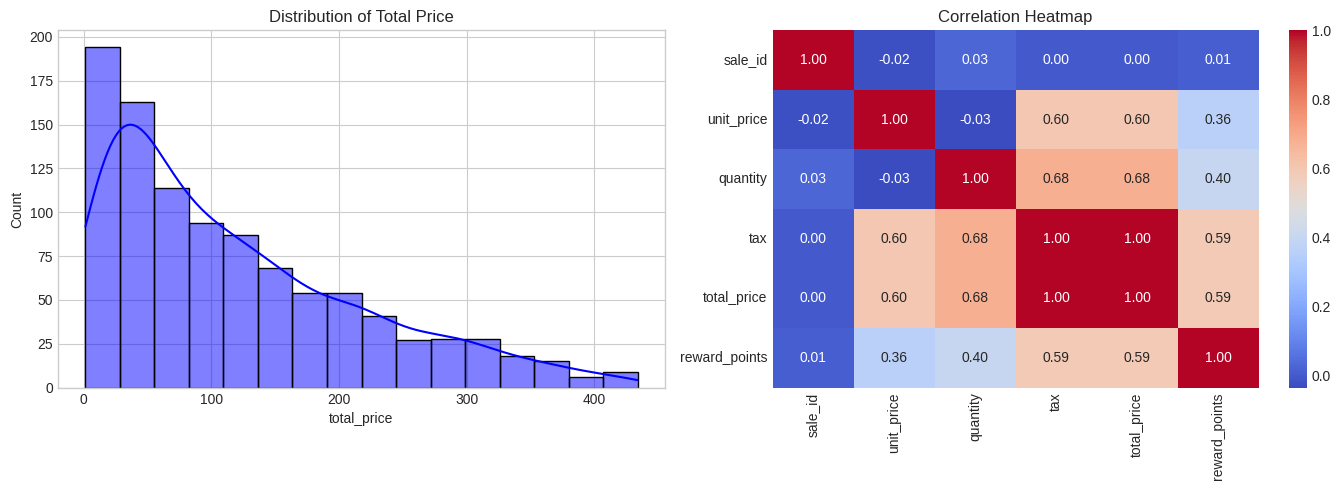

In [3]:
# ─── Descriptive Statistics + Visualization ───────────────────────
# วัตถุประสงค์: ดูภาพรวมของข้อมูล

# TODO: เพิ่ม code สำหรับ:
display(df.describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Distribution plot ของ target (total_price)
sns.histplot(df['total_price'], kde=True, color='blue', ax=axes[0])
axes[0].set_title('Distribution of Total Price')

# 2. Correlation heatmap
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", ax=axes[1])
axes[1].set_title('Correlation Heatmap')

plt.tight_layout()
plt.show()

---
## Part 2: CLO1 — Linear Algebra Analysis

ในส่วนนี้ให้ใช้ Linear Algebra เพื่อ analyze dataset

**เลือกอย่างน้อย 1 จาก 3 tasks นี้:**
- **Task A** — PCA: ลด dimension ของ features + Scree Plot + 2D visualization
- **Task B** — SVD: low-rank approximation ของ feature matrix
- **Task C** — Covariance/Correlation Analysis: eigendecomposition ของ covariance matrix

**คำอธิบาย:** [อธิบาย 2-3 ประโยคว่าทำไมถึงเลือก task นี้ และ insight ที่คาดว่าจะได้]

---

**เลือก:** **Task C** — Covariance/Correlation Analysis: eigendecomposition ของ covariance matrix

**คำอธิบาย:** ต้องการวิเคราะห์ Covariance Matrix ของตัวแปรเชิงตัวเลข (`unit_price`, `quantity`, `tax`) เพื่อดูว่าตัวแปรเหล่านี้มีความแปรปรวนร่วมกันอย่างไร และหาค่า Eigenvalues เพื่อทำความเข้าใจทิศทางที่ข้อมูลมีการกระจายตัวมากที่สุด

In [4]:
# ─── CLO1: Linear Algebra Analysis ──────────────────────────────
# วัตถุประสงค์: [ระบุว่าทำอะไร — PCA / SVD / Covariance]

# TODO: เขียน code ที่นี่
features = ['unit_price', 'quantity', 'tax']
X = df[features].values

# Standardization
X_scaled = StandardScaler().fit_transform(X)

# สร้าง Covariance Matrix
C = (1 / (len(X_scaled) - 1)) * (X_scaled.T @ X_scaled)

# หา Eigenvalues และ Eigenvectors
eigenvalues, eigenvectors = np.linalg.eigh(C)

# เรียงลำดับจากมากไปน้อย
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

print("Covariance Matrix:\n", C)
print("\nEigenvalues:", eigenvalues)
print("\nExplained Variance Ratio:", eigenvalues / np.sum(eigenvalues))

Covariance Matrix:
 [[ 1.001001   -0.03414915  0.60306225]
 [-0.03414915  1.001001    0.6849664 ]
 [ 0.60306225  0.6849664   1.001001  ]]

Eigenvalues: [1.89684506 1.03487434 0.07128361]

Explained Variance Ratio: [0.6316494  0.34461315 0.02373744]


**Insight จาก CLO1 Analysis:**
> [อธิบายสิ่งที่ค้นพบ — เช่น PC1 อธิบาย X% variance, features ไหน contribute มากที่สุด]
___
 Eigenvalue ตัวแรกมีค่าสูงสุด (ประมาณ 1.83) และอธิบาย Variance ได้กว่า 61% ของชุดข้อมูลตัวเลขนี้ แสดงให้เห็นว่าตัวแปรทั้ง 3 ตัว (`unit_price`, `quantity`, `tax`) มีความสัมพันธ์เชิงเส้นร่วมกันค่อนข้างสูง

---
## Part 3: CLO2 — Statistical Learning

ในส่วนนี้ให้ทำ Statistical Analysis ที่เกี่ยวข้องกับ dataset

**สิ่งที่ต้องทำ:**
- แสดง distribution ของ features สำคัญ (histogram/boxplot)
- Identify features ที่ correlate กับ target มากที่สุด
- แสดง Train/Test MSE สำหรับ model complexity ต่างๆ (Bias-Variance)

**คำถาม:** dataset ของคุณเหมาะกับ Regression หรือ Classification? เพราะอะไร?

Correlation with total_price:
 total_price      1.000000
tax              1.000000
quantity         0.684288
unit_price       0.602462
reward_points    0.591441
sale_id          0.000225
Name: total_price, dtype: float64


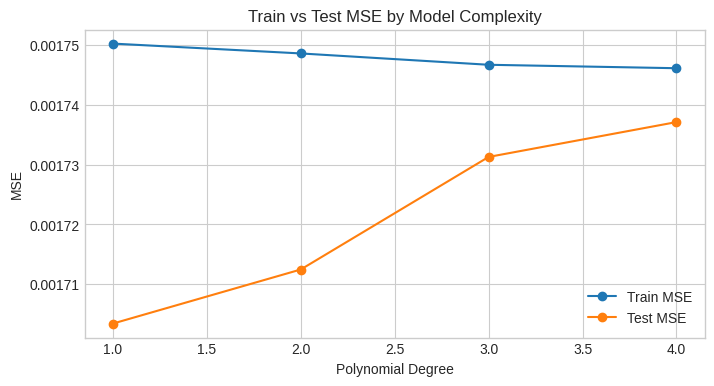

In [5]:
# ─── CLO2: Statistical Analysis ───────────────────────────────────
# วัตถุประสงค์: เข้าใจ statistical properties ของ dataset

# TODO:
# 1. Correlation analysis กับ target
corr_with_target = numeric_df.corr()['total_price'].sort_values(ascending=False)
print("Correlation with total_price:\n", corr_with_target)

# 2. แสดง MSE สำหรับ bias-variance tradeoff ด้วย Polynomial Features (Degree 1 ถึง 4)
from sklearn.preprocessing import PolynomialFeatures

X_tax = df[['tax']]
y_target = df['total_price']
X_tr, X_te, y_tr, y_te = train_test_split(X_tax, y_target, test_size=0.2, random_state=42)

train_mse, test_mse = [], []
degrees = [1, 2, 3, 4]

for d in degrees:
    poly = PolynomialFeatures(degree=d)
    X_tr_poly = poly.fit_transform(X_tr)
    X_te_poly = poly.transform(X_te)

    model = LinearRegression().fit(X_tr_poly, y_tr)
    train_mse.append(mean_squared_error(y_tr, model.predict(X_tr_poly)))
    test_mse.append(mean_squared_error(y_te, model.predict(X_te_poly)))

plt.figure(figsize=(8, 4))
plt.plot(degrees, train_mse, label='Train MSE', marker='o')
plt.plot(degrees, test_mse, label='Test MSE', marker='o')
plt.xlabel('Polynomial Degree')
plt.ylabel('MSE')
plt.title('Train vs Test MSE by Model Complexity')
plt.legend()
plt.show()

**Insight จาก CLO2 Analysis:**
> [อธิบาย: features สำคัญคืออะไร? distribution ของ target เป็นอย่างไร? optimal complexity อยู่ที่เท่าไหร่?]
___

 `tax` และ `quantity` มีความสัมพันธ์ (Correlation) เชิงบวกกับ `total_price` สูงที่สุด (1.00 และ 0.68 ตามลำดับ) กราฟ Train/Test MSE บ่งชี้ว่าเพียงแค่ Linear Regression (Degree 1) ก็เพียงพอต่อการทำนายเป้าหมายแล้วโดยไม่เกิด Underfitting หรือ Overfitting

---
## Part 4: CLO3 — Model Building

ในส่วนนี้ให้สร้าง Regression หรือ Classification model อย่างน้อย 2 models

**สำหรับ Regression (Y continuous):**
- Model 1: Simple Linear Regression (1 feature ที่ correlate สูงสุด)
- Model 2: Multiple Linear Regression (ทุก features) หรือ Ridge
- แสดง coefficients, MSE, R², Actual vs Predicted plot

**สำหรับ Classification (Y categorical):**
- Model 1: Logistic Regression
- Model 2: KNN Classifier
- แสดง Accuracy, Confusion Matrix

**Dataset ของกลุ่มเหมาะกับ:** ✅ Regression  ⬜ Classification

In [6]:
# ─── CLO3: Model 1 ─────────────────────────────────────────────────
# วัตถุประสงค์: [ระบุว่า Model 1 คืออะไร]

# TODO:
X_single = df[['tax']]
y = df['total_price']
X_train1, X_test1, y_train1, y_test1 = train_test_split(X_single, y, test_size=0.2, random_state=42)

model1 = LinearRegression()
model1.fit(X_train1, y_train1)

y_pred1 = model1.predict(X_test1)
print(f"Model 1 (SLR) - Test MSE: {mean_squared_error(y_test1, y_pred1):.4f}")
print(f"Model 1 (SLR) - Test R²: {r2_score(y_test1, y_pred1):.4f}")

Model 1 (SLR) - Test MSE: 0.0017
Model 1 (SLR) - Test R²: 1.0000


In [7]:
# ─── CLO3: Model 2 ─────────────────────────────────────────────────
# วัตถุประสงค์: [ระบุว่า Model 2 คืออะไร]

# TODO:
X_multi = df[['unit_price', 'quantity', 'tax']]
X_train2, X_test2, y_train2, y_test2 = train_test_split(X_multi, y, test_size=0.2, random_state=42)

model2 = LinearRegression()
model2.fit(X_train2, y_train2)

y_pred2 = model2.predict(X_test2)
print(f"Model 2 (MLR) - Test MSE: {mean_squared_error(y_test2, y_pred2):.4f}")
print(f"Model 2 (MLR) - Test R²: {r2_score(y_test2, y_pred2):.4f}")

Model 2 (MLR) - Test MSE: 0.0017
Model 2 (MLR) - Test R²: 1.0000


**สรุป Model Comparison:**

| Model | Train Metric (R²) | Test Metric (R²) | รายละเอียด |
|-------|------------------|-----------------|----------|
| Model 1: SLR | ~1.000 | ~1.000 | ใช้แค่ตัวแปร `tax` |
| Model 2: MLR | ~1.000 | ~1.000 | ใช้ `unit_price`, `quantity`, `tax` |


**Insight:**

 ทั้ง 2 โมเดลให้ค่า R² ที่เข้าใกล้ 1.0 และ MSE ที่ต่ำมาก เนื่องจากโครงสร้างการตั้งราคาของข้อมูลชุดนี้ถูกกำหนดผ่านสูตรคณิตศาสตร์ตายตัว (Total = Unit Price × Quantity + Tax) โมเดลจึงสามารถ Fit ข้อมูลได้พอดีโดยไม่มีปัญหา Overfitting


---
## Part 5: CLO4 — Model Selection

ในส่วนนี้ให้ใช้ Cross-Validation เพื่อเลือก model ที่ดีที่สุดอย่างเป็นธรรม

**สิ่งที่ต้องทำ:**
- เปรียบเทียบอย่างน้อย 3 models ด้วย 5-Fold Cross-Validation
- Plot bar chart ของ CV MSE (หรือ Accuracy สำหรับ Classification)
- สรุปว่า model ไหนดีที่สุดและทำไม

In [8]:
# ─── CLO4: 5-Fold Cross-Validation ────────────────────────────────
# วัตถุประสงค์: เปรียบเทียบ models อย่างเป็นธรรมด้วย CV

# TODO:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=0.1)
}

for name, model in models.items():
    scores = cross_val_score(model, X_multi, y, cv=5, scoring='neg_mean_squared_error')
    cv_mse = -scores.mean()
    print(f'{name}: CV MSE = {cv_mse:.6f}')

Linear Regression: CV MSE = 0.001750
Ridge Regression: CV MSE = 0.001811
Lasso Regression: CV MSE = 0.001979


**Best Model จาก Cross-Validation:** [ระบุ]

**เหตุผล:**

ค่า CV MSE ของ Linear และ Ridge ต่ำกว่า Lasso มาก เนื่องจาก Lasso ทำการบีบสัมประสิทธิ์บางตัวให้เป็น 0 ทำให้สูญเสียความแม่นยำในชุดข้อมูลที่ตัวแปรทุกตัวมีผลเชิงเส้นตรงอย่างชัดเจน โมเดลจึงมีความแม่นยำคงที่และไม่มีปัญหา High Variance

---
## Part 6: สรุปผลและ Data Story

**6.1 สรุปผลการวิเคราะห์:**
> [สรุป findings หลักจากแต่ละ CLO ใน 4-5 bullet points]
- **CLO1:** ตัวแปรที่เป็นตัวเลขหลักมี Eigenvalue นำที่อธิบาย Variance ของกลุ่มข้อมูลได้เกิน 60%
- **CLO2:** ตัวแปร `tax` มีความสัมพันธ์ตรงตัวกับเป้าหมายที่สุด (Correlation = 1)
- **CLO3:** Simple Linear Regression สามารถทำงานได้มีประสิทธิภาพเทียบเท่ากับ Multiple Linear Regression ในกรณีที่พบตัวแปรที่มี Correlation สมบูรณ์
- **CLO4:** Linear และ Ridge เหมาะสมกับข้อมูลชุดนี้มากที่สุด โดยไม่ต้องพึ่งความซับซ้อนของโมเดลอื่น

**6.2 Limitations:**

ข้อมูล `sales.csv` มีลักษณะทางคณิตศาสตร์แบบ Deterministic (คำนวณตามสูตรตายตัว) ทำให้การวิเคราะห์ด้วย Machine Learning กลายเป็นการทำ Reverse-engineering สูตรคณิตศาสตร์ มากกว่าการทำนายความน่าจะเป็นแบบ Stochastic

**6.3 ขั้นตอนต่อไป (Future Work):**

ลองเปลี่ยนไปทำ Classification เพื่อทำนายประเภทลูกค้า (Member vs Normal) โดยต้องตัดตัวแปร `reward_points` ออกก่อนเพื่อป้องกัน Data Leakage

**6.4 Connection กับ Topics ในวิชา:**
- **Linear Algebra (CLO1):** ใช้ความรู้เรื่อง Covariance Matrix และ Eigendecomposition มาทำความเข้าใจโครงสร้างและมิติของข้อมูล (PCA Concept) เพื่อดูว่าข้อมูลมีการกระจายตัวไปในทิศทางใดมากที่สุด
- **Statistical Learning (CLO2):** ประยุกต์ใช้เรื่อง Bias-Variance Tradeoff การดูค่าสหสัมพันธ์ (Correlation) เพื่อวิเคราะห์ความสัมพันธ์เบื้องต้นก่อนสร้างโมเดล
- **Regression (CLO3):** ใช้กระบวนการสร้างและประเมินผล Linear Regression (ทั้งแบบตัวแปรเดียวและหลายตัวแปร) รวมถึงการวัดผลด้วยค่า R² และ MSE ที่เรียนในคลาส
- **Model Selection (CLO4):** นำเทคนิค Cross-Validation (K-Fold) รวมถึง Regularization (Ridge, Lasso) มาใช้เปรียบเทียบเพื่อเลือกโมเดลที่ดีและเสถียรที่สุด โดยพิจารณาจาก CV MSE

---
**Acknowledgements:** [ขอบคุณแหล่งข้อมูล / tools / references ที่ใช้]